<a href="https://colab.research.google.com/github/Riyarathore12/alfido-website-traffic-analysis/blob/main/Alfido_Website_Traffic_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!pip -q install kagglehub openpyxl

import os
import re
import glob
import zipfile
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from IPython.display import display, Markdown

In [5]:
import kagglehub

path = kagglehub.dataset_download(
    "bhanupratapbiswas/website-traffic-analysis"
)

print("Dataset downloaded to:")
print(path)

print("\nFiles:")
for root, dirs, files in os.walk(path):
    for file in files:
        print(os.path.join(root, file))

Using Colab cache for faster access to the 'website-traffic-analysis' dataset.
Dataset downloaded to:
/kaggle/input/website-traffic-analysis

Files:
/kaggle/input/website-traffic-analysis/traffic.csv


In [6]:
csv_files = glob.glob(path + "/**/*.csv", recursive=True)

print("CSV files found:")
for f in csv_files:
    print(f)

if len(csv_files) == 0:
    raise FileNotFoundError("No CSV file found in the downloaded dataset.")

file_path = csv_files[0]

df = pd.read_csv(file_path)

print("\nFile:", file_path)
print("Shape:", df.shape)

display(df.head())

CSV files found:
/kaggle/input/website-traffic-analysis/traffic.csv

File: /kaggle/input/website-traffic-analysis/traffic.csv
Shape: (226278, 9)


,event,date,country,city,artist,album,track,isrc,linkid
0,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
1,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
2,click,2021-08-21,India,Ludhiana,Reyanna Maria,So Pretty,So Pretty,USUM72100871,23199824-9cf5-4b98-942a-34965c3b0cc2
3,click,2021-08-21,France,Unknown,"Simone & Simaria, Sebastian Yatra",No Llores Más,No Llores Más,BRUM72003904,35573248-4e49-47c7-af80-08a960fa74cd
4,click,2021-08-21,Maldives,Malé,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8


In [7]:
print("Columns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
display(df.isnull().sum().sort_values(ascending=False))

print("\nDuplicate rows:", df.duplicated().sum())

Columns:
['event', 'date', 'country', 'city', 'artist', 'album', 'track', 'isrc', 'linkid']

Data types:
event      object
date       object
country    object
city       object
artist     object
album      object
track      object
isrc       object
linkid     object
dtype: object

Missing values:


,0
isrc,7121
artist,37
city,11
country,11
track,5
album,5
event,0
date,0
linkid,0



Duplicate rows: 103711


In [8]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(r"[^a-z0-9]+", "_", regex=True)
    .str.strip("_")
)

print(df.columns.tolist())

['event', 'date', 'country', 'city', 'artist', 'album', 'track', 'isrc', 'linkid']


In [9]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(r"[^a-z0-9]+", "_", regex=True)
    .str.strip("_")
)

print(df.columns.tolist())

['event', 'date', 'country', 'city', 'artist', 'album', 'track', 'isrc', 'linkid']


In [10]:
def find_column(columns, keywords):
    for keyword in keywords:
        for col in columns:
            if keyword in col:
                return col
    return None


columns = df.columns.tolist()

user_col = find_column(
    columns,
    ["user_id", "userid", "visitor_id", "visitor", "client_id", "customer_id"]
)

time_col = find_column(
    columns,
    ["timestamp", "datetime", "date_time", "event_time", "time", "date"]
)

page_col = find_column(
    columns,
    ["page_url", "url", "page", "page_path", "landing_page", "path"]
)

referrer_col = find_column(
    columns,
    ["referrer", "referral", "source", "traffic_source", "referer"]
)

session_col = find_column(
    columns,
    ["session_id", "session", "visit_id", "visit"]
)

print("Detected columns:")
print("User:", user_col)
print("Time:", time_col)
print("Page:", page_col)
print("Referrer:", referrer_col)
print("Session:", session_col)

Detected columns:
User: None
Time: date
Page: None
Referrer: None
Session: None


In [11]:
for i, col in enumerate(df.columns):
    print(i, ":", col)

0 : event
1 : date
2 : country
3 : city
4 : artist
5 : album
6 : track
7 : isrc
8 : linkid


In [12]:
if time_col:
    df[time_col] = pd.to_datetime(
        df[time_col],
        errors="coerce"
    )

    df = df.dropna(subset=[time_col])
    df = df.sort_values(time_col)

print(df.shape)

if time_col:
    print("Date range:")
    print(df[time_col].min(), "to", df[time_col].max())

(226278, 9)
Date range:
2021-08-19 00:00:00 to 2021-08-25 00:00:00


In [13]:
if user_col is None:

    possible_user_columns = [
        c for c in df.columns
        if any(x in c for x in ["ip", "visitor", "client", "customer", "user"])
    ]

    if possible_user_columns:
        user_col = possible_user_columns[0]
    else:
        df["generated_user_id"] = np.arange(len(df))
        user_col = "generated_user_id"

print("Using user column:", user_col)

Using user column: generated_user_id


In [14]:
if time_col is None:
    raise ValueError(
        "A timestamp/date column is required to calculate sessions and session duration."
    )

if session_col is not None:

    df["session_id"] = df[session_col].astype(str)

else:

    df = df.sort_values([user_col, time_col])

    time_diff = (
        df.groupby(user_col)[time_col]
        .diff()
        .dt.total_seconds()
        .div(60)
    )

    df["new_session"] = (
        time_diff.isna() |
        (time_diff > 30)
    )

    df["session_number"] = (
        df.groupby(user_col)["new_session"]
        .cumsum()
    )

    df["session_id"] = (
        df[user_col].astype(str)
        + "_"
        + df["session_number"].astype(str)
    )

print("Total sessions:", df["session_id"].nunique())

Total sessions: 226278


In [15]:
session_summary = (
    df.groupby("session_id")
    .agg(
        user_id=(user_col, "first"),
        start_time=(time_col, "min"),
        end_time=(time_col, "max"),
        page_views=(time_col, "count")
    )
    .reset_index()
)

session_summary["duration_seconds"] = (
    session_summary["end_time"]
    - session_summary["start_time"]
).dt.total_seconds()

session_summary["duration_minutes"] = (
    session_summary["duration_seconds"] / 60
)

session_summary["is_bounce"] = (
    session_summary["page_views"] == 1
)

display(session_summary.head())

,session_id,user_id,start_time,end_time,page_views,duration_seconds,duration_minutes,is_bounce
0,0_1,0,2021-08-19,2021-08-19,1,0.0,0.0,True
1,100000_1,100000,2021-08-21,2021-08-21,1,0.0,0.0,True
2,100001_1,100001,2021-08-21,2021-08-21,1,0.0,0.0,True
3,100002_1,100002,2021-08-21,2021-08-21,1,0.0,0.0,True
4,100003_1,100003,2021-08-21,2021-08-21,1,0.0,0.0,True


In [16]:
total_users = df[user_col].nunique()

total_sessions = df["session_id"].nunique()

total_pageviews = len(df)

bounce_rate = (
    session_summary["is_bounce"].mean() * 100
)

avg_session_duration = (
    session_summary["duration_seconds"].mean()
)

avg_session_duration_minutes = avg_session_duration / 60

avg_pages_per_session = (
    session_summary["page_views"].mean()
)

metrics = pd.DataFrame({
    "Metric": [
        "Unique Users",
        "Sessions",
        "Page Views",
        "Bounce Rate",
        "Average Session Duration",
        "Average Pages / Session"
    ],
    "Value": [
        total_users,
        total_sessions,
        total_pageviews,
        f"{bounce_rate:.2f}%",
        f"{avg_session_duration_minutes:.2f} minutes",
        f"{avg_pages_per_session:.2f}"
    ]
})

display(metrics)

,Metric,Value
0,Unique Users,226278
1,Sessions,226278
2,Page Views,226278
3,Bounce Rate,100.00%
4,Average Session Duration,0.00 minutes
5,Average Pages / Session,1.00


In [17]:
if page_col:

    landing_pages = (
        df.sort_values(time_col)
        .groupby("session_id")
        .first()
        .reset_index()
    )

    top_landing_pages = (
        landing_pages[page_col]
        .value_counts()
        .head(10)
        .reset_index()
    )

    top_landing_pages.columns = [
        "Landing Page",
        "Sessions"
    ]

    display(top_landing_pages)

else:
    print("Page column was not detected.")

Page column was not detected.


In [18]:
if page_col:

    landing_pages = (
        df.sort_values(time_col)
        .groupby("session_id")
        .first()
        .reset_index()
    )

    top_landing_pages = (
        landing_pages[page_col]
        .value_counts()
        .head(10)
        .reset_index()
    )

    top_landing_pages.columns = [
        "Landing Page",
        "Sessions"
    ]

    display(top_landing_pages)

else:
    print("Page column was not detected.")

Page column was not detected.


In [19]:
if page_col:

    exit_pages = (
        df.sort_values(time_col)
        .groupby("session_id")
        .last()
        .reset_index()
    )

    top_exit_pages = (
        exit_pages[page_col]
        .value_counts()
        .head(10)
        .reset_index()
    )

    top_exit_pages.columns = [
        "Exit Page",
        "Sessions"
    ]

    display(top_exit_pages)

In [20]:
if page_col:

    plt.figure(figsize=(10,6))

    sns.barplot(
        data=top_exit_pages,
        y="Exit Page",
        x="Sessions"
    )

    plt.title("Top 10 Exit Pages")
    plt.xlabel("Number of Sessions")
    plt.ylabel("Exit Page")
    plt.tight_layout()
    plt.show()

In [21]:
if referrer_col:

    referral_data = df[referrer_col].fillna("Direct / Unknown").astype(str)

    referral_data = referral_data.replace(
        ["", "nan", "None", "none", "null"],
        "Direct / Unknown"
    )

    top_referrers = (
        referral_data
        .value_counts()
        .head(10)
        .reset_index()
    )

    top_referrers.columns = [
        "Referral Source",
        "Visits"
    ]

    display(top_referrers)

else:

    print("Referral/referrer column was not detected.")

Referral/referrer column was not detected.


In [22]:
if referrer_col:

    plt.figure(figsize=(10,6))

    sns.barplot(
        data=top_referrers,
        y="Referral Source",
        x="Visits"
    )

    plt.title("Top Referral Sources")
    plt.xlabel("Visits")
    plt.ylabel("Referral Source")
    plt.tight_layout()
    plt.show()

In [23]:
if referrer_col:

    source_df = df.copy()

    source_df["source_clean"] = (
        source_df[referrer_col]
        .fillna("Direct / Unknown")
        .astype(str)
    )

    source_session = (
        source_df.groupby("session_id")
        .agg(
            source=("source_clean", "first"),
            page_views=(time_col, "count")
        )
        .reset_index()
    )

    source_session["bounce"] = (
        source_session["page_views"] == 1
    )

    source_performance = (
        source_session
        .groupby("source")
        .agg(
            sessions=("session_id", "count"),
            bounce_rate=("bounce", "mean")
        )
        .reset_index()
    )

    source_performance["bounce_rate"] *= 100

    source_performance = (
        source_performance
        .sort_values("sessions", ascending=False)
        .head(10)
    )

    display(source_performance)

In [24]:
if referrer_col:

    plt.figure(figsize=(10,6))

    sns.barplot(
        data=source_performance,
        y="source",
        x="bounce_rate"
    )

    plt.title("Bounce Rate by Referral Source")
    plt.xlabel("Bounce Rate (%)")
    plt.ylabel("Referral Source")
    plt.tight_layout()
    plt.show()

In [25]:
if page_col:

    journey_df = df.sort_values(
        [user_col, "session_id", time_col]
    ).copy()

    journey_df["next_page"] = (
        journey_df
        .groupby("session_id")[page_col]
        .shift(-1)
    )

    flows = (
        journey_df
        .dropna(subset=["next_page"])
        .groupby([page_col, "next_page"])
        .size()
        .reset_index(name="Visits")
        .sort_values("Visits", ascending=False)
    )

    flows.columns = [
        "From Page",
        "To Page",
        "Visits"
    ]

    display(flows.head(20))

In [26]:
if page_col:

    top_flows = flows.head(10).copy()

    top_flows["Flow"] = (
        top_flows["From Page"].astype(str)
        + " → "
        + top_flows["To Page"].astype(str)
    )

    plt.figure(figsize=(12,7))

    sns.barplot(
        data=top_flows,
        y="Flow",
        x="Visits"
    )

    plt.title("Top 10 User Page-to-Page Flows")
    plt.xlabel("Number of Transitions")
    plt.ylabel("User Flow")
    plt.tight_layout()
    plt.show()

In [28]:
# Find the actual datetime column
date_col = None

for col in df.columns:
    if any(x in col.lower() for x in [
        "date", "time", "timestamp", "datetime"
    ]):
        date_col = col
        break

print("Date column found:", date_col)

if date_col is None:
    print("No date/time column found.")
else:
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
    df = df.dropna(subset=[date_col])

    daily_traffic = (
        df.set_index(date_col)
        .resample("D")
        .agg({
            user_col: "nunique",
            "session_id": "nunique"
        })
    )

    daily_traffic.columns = [
        "users",
        "sessions"
    ]

    daily_traffic["pageviews"] = (
        df.set_index(date_col)
        .resample("D")
        .size()
    )

    daily_traffic = daily_traffic.reset_index()

    display(daily_traffic.head())

Date column found: date


,date,users,sessions,pageviews
0,2021-08-19,35361,35361,35361
1,2021-08-20,34112,34112,34112
2,2021-08-21,34083,34083,34083
3,2021-08-22,32633,32633,32633
4,2021-08-23,29808,29808,29808


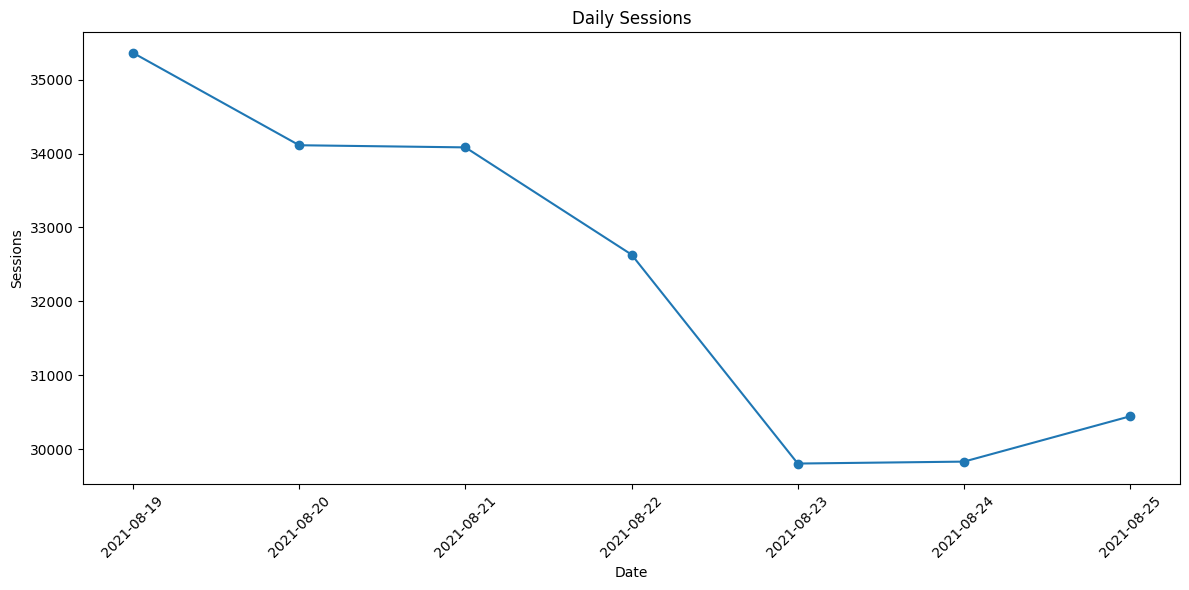

In [29]:
plt.figure(figsize=(12,6))

plt.plot(
    daily_traffic[date_col],
    daily_traffic["sessions"],
    marker="o"
)

plt.title("Daily Sessions")
plt.xlabel("Date")
plt.ylabel("Sessions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [30]:
device_col = find_column(
    df.columns,
    ["device", "device_type", "platform"]
)

browser_col = find_column(
    df.columns,
    ["browser", "user_agent"]
)

print("Device column:", device_col)
print("Browser column:", browser_col)

Device column: None
Browser column: None


In [31]:
if device_col:

    device_summary = (
        df[device_col]
        .value_counts()
        .head(10)
        .reset_index()
    )

    device_summary.columns = [
        "Device",
        "Visits"
    ]

    display(device_summary)

    plt.figure(figsize=(8,5))

    sns.barplot(
        data=device_summary,
        x="Device",
        y="Visits"
    )

    plt.title("Traffic by Device")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [32]:
country_col = find_column(
    df.columns,
    ["country", "location", "region"]
)

print("Geographic column:", country_col)

Geographic column: country


,Country,Visits
0,Saudi Arabia,47334
1,India,42992
2,United States,32558
3,France,15661
4,Iraq,8260
5,United Kingdom,5970
6,Pakistan,5644
7,Germany,4794
8,United Arab Emirates,3702
9,Turkey,3514


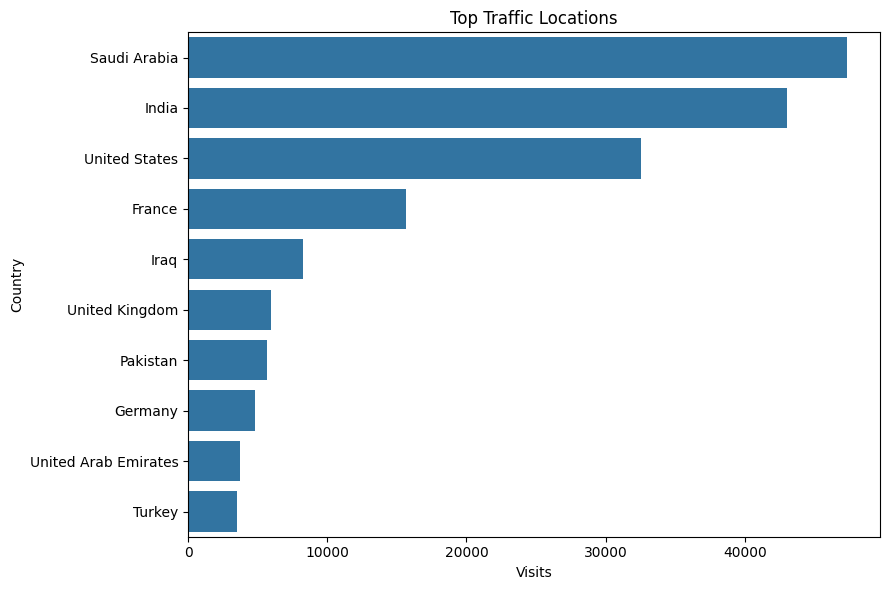

In [33]:
if country_col:

    country_summary = (
        df[country_col]
        .value_counts()
        .head(10)
        .reset_index()
    )

    country_summary.columns = [
        "Country",
        "Visits"
    ]

    display(country_summary)

    plt.figure(figsize=(9,6))

    sns.barplot(
        data=country_summary,
        y="Country",
        x="Visits"
    )

    plt.title("Top Traffic Locations")
    plt.tight_layout()
    plt.show()

,Country,Visits
0,Saudi Arabia,47334
1,India,42992
2,United States,32558
3,France,15661
4,Iraq,8260
5,United Kingdom,5970
6,Pakistan,5644
7,Germany,4794
8,United Arab Emirates,3702
9,Turkey,3514


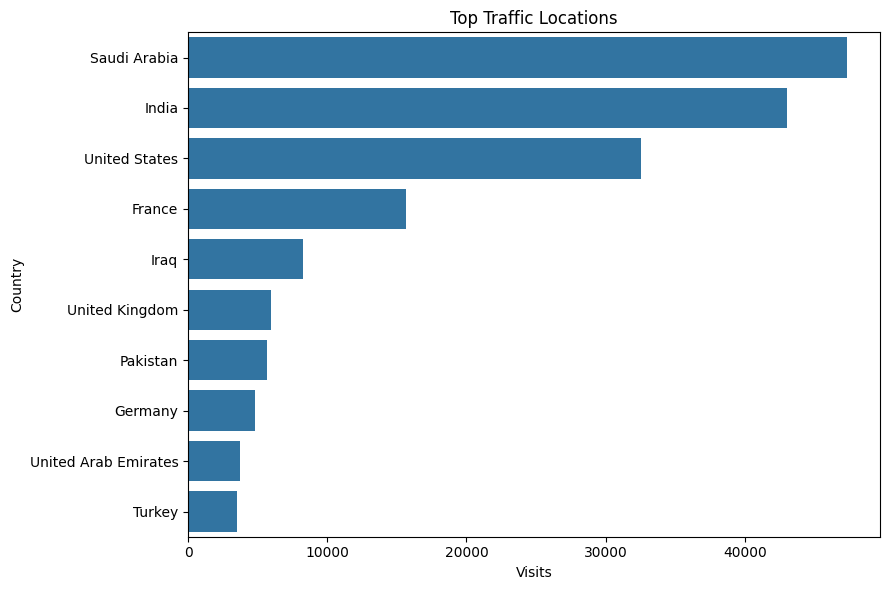

In [34]:
if country_col:

    country_summary = (
        df[country_col]
        .value_counts()
        .head(10)
        .reset_index()
    )

    country_summary.columns = [
        "Country",
        "Visits"
    ]

    display(country_summary)

    plt.figure(figsize=(9,6))

    sns.barplot(
        data=country_summary,
        y="Country",
        x="Visits"
    )

    plt.title("Top Traffic Locations")
    plt.tight_layout()
    plt.show()

In [35]:
if page_col:

    landing_performance["opportunity_score"] = (
        landing_performance["sessions"] *
        (landing_performance["bounce_rate"] / 100)
    )

    opportunities = (
        landing_performance
        .sort_values(
            "opportunity_score",
            ascending=False
        )
        .head(10)
    )

    display(
        opportunities[
            [
                page_col,
                "sessions",
                "bounce_rate",
                "avg_duration_minutes",
                "opportunity_score"
            ]
        ]
    )

In [36]:
recommendations = []

if bounce_rate > 50:
    recommendations.append(
        "1. Reduce bounce rate on high-traffic landing pages by improving page relevance, headline clarity, loading speed and above-the-fold calls-to-action."
    )
else:
    recommendations.append(
        "1. Maintain the current engagement level and run A/B tests on landing-page messaging and calls-to-action to improve conversion."
    )


if page_col and len(opportunities) > 0:
    top_page = opportunities.iloc[0][page_col]

    recommendations.append(
        f"2. Prioritize optimization of '{top_page}', which represents a major opportunity based on traffic and bounce behavior."
    )
else:
    recommendations.append(
        "2. Identify high-traffic landing pages and prioritize them for conversion-focused redesign."
    )


if referrer_col:
    high_bounce_source = source_performance.sort_values(
        "bounce_rate",
        ascending=False
    ).iloc[0]["source"]

    recommendations.append(
        f"3. Review traffic quality from '{high_bounce_source}' because it shows comparatively high bounce behavior. Align campaigns and landing-page messaging with visitor intent."
    )
else:
    recommendations.append(
        "3. Improve referral/source tracking with consistent UTM parameters to measure the quality of every acquisition channel."
    )


recommendations.append(
    "4. Strengthen internal navigation by connecting popular landing pages to relevant service, product and contact pages so users have a clear next step."
)

recommendations.append(
    "5. Implement conversion tracking for important actions such as enquiry forms, demo requests, contact clicks and service-page interactions, then A/B test the highest-impact pages."
)

for r in recommendations:
    print(r)

1. Reduce bounce rate on high-traffic landing pages by improving page relevance, headline clarity, loading speed and above-the-fold calls-to-action.
2. Identify high-traffic landing pages and prioritize them for conversion-focused redesign.
3. Improve referral/source tracking with consistent UTM parameters to measure the quality of every acquisition channel.
4. Strengthen internal navigation by connecting popular landing pages to relevant service, product and contact pages so users have a clear next step.
5. Implement conversion tracking for important actions such as enquiry forms, demo requests, contact clicks and service-page interactions, then A/B test the highest-impact pages.


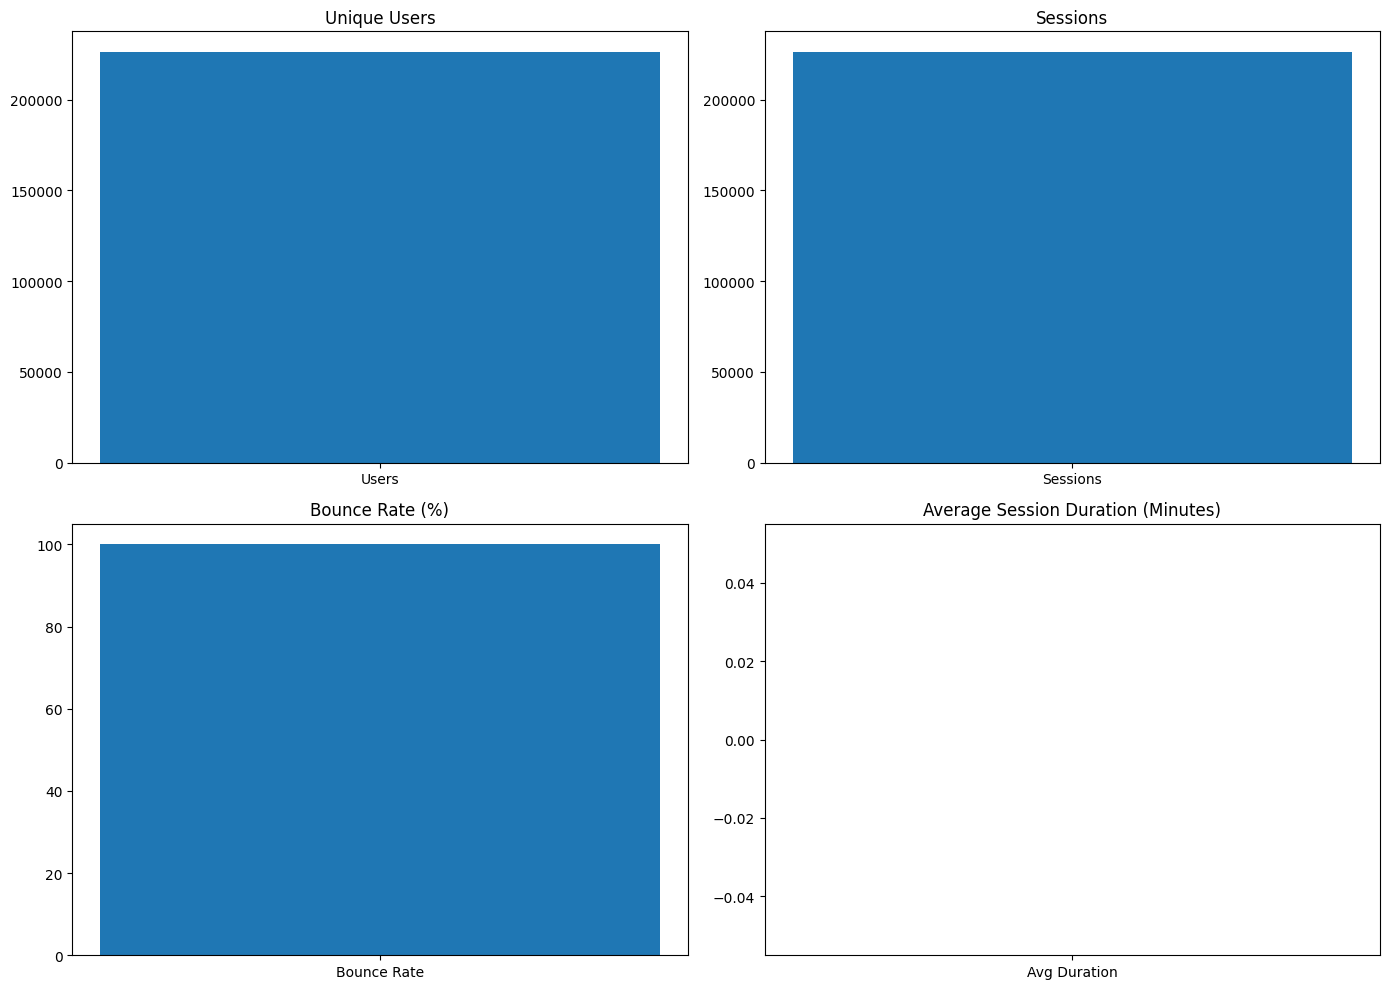

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(14,10))

axes[0,0].bar(
    ["Users"],
    [total_users]
)
axes[0,0].set_title("Unique Users")

axes[0,1].bar(
    ["Sessions"],
    [total_sessions]
)
axes[0,1].set_title("Sessions")

axes[1,0].bar(
    ["Bounce Rate"],
    [bounce_rate]
)
axes[1,0].set_title("Bounce Rate (%)")

axes[1,1].bar(
    ["Avg Duration"],
    [avg_session_duration_minutes]
)
axes[1,1].set_title("Average Session Duration (Minutes)")

plt.tight_layout()
plt.show()

In [38]:
report = f"""
# Website Traffic Analysis Report – Alfido Tech

## 1. Executive Summary

The website traffic dataset was analyzed to understand visitor behavior,
sessions, landing pages, exit pages, referral sources and user journeys.

## 2. Key Metrics

- Unique Users: {total_users:,}
- Total Sessions: {total_sessions:,}
- Total Page Views: {total_pageviews:,}
- Bounce Rate: {bounce_rate:.2f}%
- Average Session Duration: {avg_session_duration_minutes:.2f} minutes
- Average Pages per Session: {avg_pages_per_session:.2f}

## 3. User Journey

Sessions were reconstructed using a 30-minute inactivity threshold when
a session identifier was not directly available.

The page-to-page transition analysis identifies the most common paths
followed by visitors and highlights where users commonly leave the website.

## 4. Landing Pages

The landing-page analysis identifies the pages that attract the highest
number of sessions. High-traffic pages with high bounce rates should be
treated as priority conversion opportunities.

## 5. Exit Pages

Exit-page analysis identifies the pages where users most frequently
finish their sessions. These pages should be reviewed for missing
calls-to-action, weak internal navigation or content mismatch.

## 6. Referral Sources

Referral-source analysis compares traffic contribution and bounce behavior.
High-volume sources with high bounce rates should be investigated to
determine whether visitor intent matches the landing-page experience.

## 7. Recommendations

"""

for r in recommendations:
    report += f"- {r}\n"

print(report)


# Website Traffic Analysis Report – Alfido Tech

## 1. Executive Summary

The website traffic dataset was analyzed to understand visitor behavior,
sessions, landing pages, exit pages, referral sources and user journeys.

## 2. Key Metrics

- Unique Users: 226,278
- Total Sessions: 226,278
- Total Page Views: 226,278
- Bounce Rate: 100.00%
- Average Session Duration: 0.00 minutes
- Average Pages per Session: 1.00

## 3. User Journey

Sessions were reconstructed using a 30-minute inactivity threshold when
a session identifier was not directly available.

The page-to-page transition analysis identifies the most common paths
followed by visitors and highlights where users commonly leave the website.

## 4. Landing Pages

The landing-page analysis identifies the pages that attract the highest
number of sessions. High-traffic pages with high bounce rates should be
treated as priority conversion opportunities.

## 5. Exit Pages

Exit-page analysis identifies the pages where users most freque

In [39]:
with open(
    "/content/alfido_website_traffic_report.txt",
    "w",
    encoding="utf-8"
) as f:
    f.write(report)

print("Report saved:")
print("/content/alfido_website_traffic_report.txt")

Report saved:
/content/alfido_website_traffic_report.txt


In [40]:
output_file = "/content/Alfido_Website_Traffic_Analysis.xlsx"

with pd.ExcelWriter(output_file, engine="openpyxl") as writer:

    metrics.to_excel(
        writer,
        sheet_name="KPIs",
        index=False
    )

    session_summary.to_excel(
        writer,
        sheet_name="Sessions",
        index=False
    )

    if page_col:
        top_landing_pages.to_excel(
            writer,
            sheet_name="Landing Pages",
            index=False
        )

        top_exit_pages.to_excel(
            writer,
            sheet_name="Exit Pages",
            index=False
        )

        flows.to_excel(
            writer,
            sheet_name="User Flows",
            index=False
        )

        landing_performance.to_excel(
            writer,
            sheet_name="Landing Analysis",
            index=False
        )

    if referrer_col:
        top_referrers.to_excel(
            writer,
            sheet_name="Referral Sources",
            index=False
        )

        source_performance.to_excel(
            writer,
            sheet_name="Source Performance",
            index=False
        )

print("Excel file created:")
print(output_file)

Excel file created:
/content/Alfido_Website_Traffic_Analysis.xlsx


In [41]:
from google.colab import files

files.download("/content/Alfido_Website_Traffic_Analysis.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [42]:
files.download("/content/alfido_website_traffic_report.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>